# **Telecom Customer Churn Prediction**
In this notebook, I worked on a telecom customer churn prediction problem to understand how machine learning can be used to identify customers who are likely to leave a service. Customer churn is an important issue in the telecom sector because losing existing customers can directly affect business performance and retention planning. Because of this, churn prediction becomes a useful machine learning task where the goal is not just to build a model, but to support better decisions.

To explore this problem properly, I followed a complete workflow that included data understanding, preprocessing, exploratory analysis, model building, tuning, and evaluation. I used five different models in this study: Logistic Regression, K-Nearest Neighbours, Random Forest, Gradient Boosting, and a Neural Network. Since the dataset was imbalanced, I also applied SMOTE and used multiple evaluation metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC to compare the models fairly.

The main aim of this notebook is to see how different machine learning approaches perform on structured telecom churn data, and to understand which model is most suitable based on both performance and practical usefulness.

Dataset Available AT:  [Telecom Customer Churn Prediction (Maven Analytics dataset on Kaggle)](https://www.kaggle.com/datasets/shilongzhuang/telecom-customer-churn-by-maven-analytics)

## Libraries

In [ ]:
# !pip install tensorflow==2.16.1 imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

# Custom palette for the whole notebook
custom_colors = ['#355070', '#6D597A', '#B56576', '#E56B6F', '#EAAC8B']

sns.set_theme(style="whitegrid")
sns.set_palette(custom_colors)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = True
plt.rcParams["font.size"] = 11

# Shared CV object
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Containers used later
results_rows = []
roc_data = {}

## Load the dataset

In [ ]:
df = pd.read_csv("telecom_customer_churn.csv")
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
print("Shape of dataset:", df.shape)
print("\nFirst few columns:")
print(df.columns.tolist()[:10])

Shape of dataset: (7043, 38)

First few columns:
['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [ ]:
missing_df = (
    df.isnull().sum()
      .reset_index()
      .rename(columns={"index": "Feature", 0: "Missing Values"})
      .sort_values("Missing Values", ascending=False)
)

missing_df.head(15)

,Feature,Missing Values
37,Churn Reason,5174
36,Churn Category,5174
11,Offer,3877
19,Online Backup,1526
17,Avg Monthly GB Download,1526
18,Online Security,1526
23,Streaming Movies,1526
22,Streaming TV,1526
25,Unlimited Data,1526
24,Streaming Music,1526


## Exploratory data analysis


### Customer status distribution as a donut chart

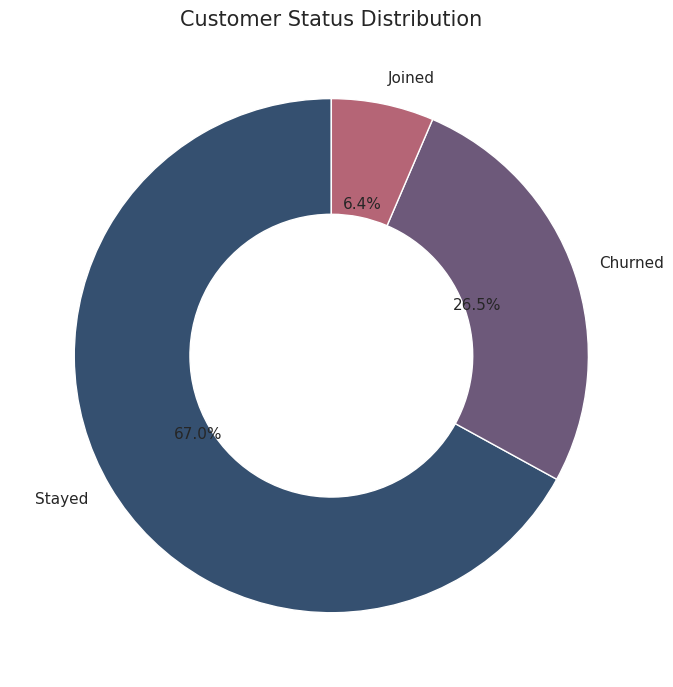

In [ ]:
status_counts = df["Customer Status"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=custom_colors[:3],
    wedgeprops=dict(width=0.45, edgecolor="white")
)
ax.set_title("Customer Status Distribution")
plt.tight_layout()
plt.show()



Most customers stayed, a smaller group churned, and a smaller group joined recently. This already tells us two things. First, the classes are not balanced. Second, the `Joined` group is not ideal for a churn model because those customers have not had enough time to fully show churn behaviour.

### Tenure pattern using a violin plot

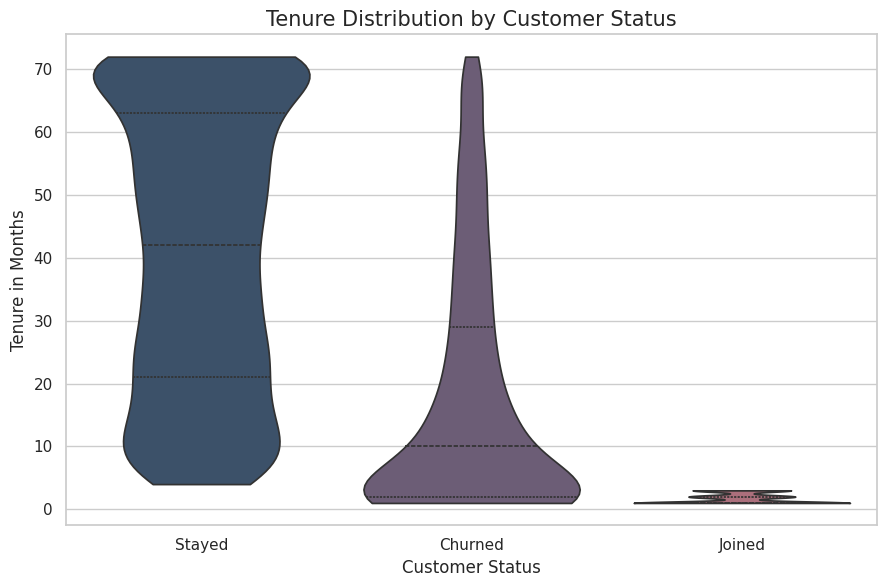

In [ ]:
plt.figure(figsize=(9, 6))
sns.violinplot(
    data=df,
    x="Customer Status",
    y="Tenure in Months",
    palette=custom_colors[:3],
    inner="quartile",
    cut=0
)
plt.title("Tenure Distribution by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Tenure in Months")
plt.tight_layout()
plt.show()



This chart shows a very clear story. Customers who stayed generally have much longer tenure, while churned customers are concentrated at lower tenure values. In simple words, many customers leave early if they do not settle into the service.

### Contract type as a proportional stacked chart

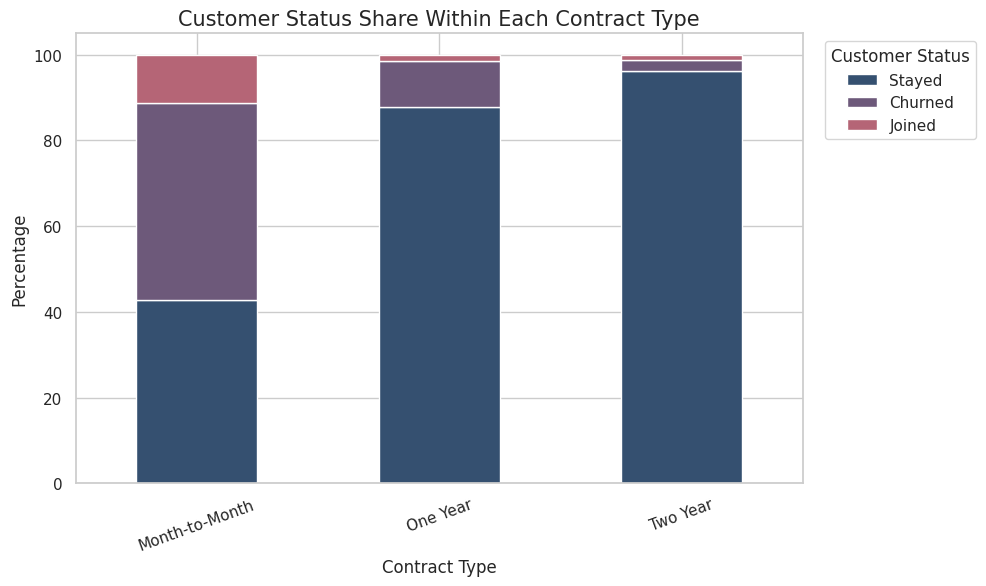

In [ ]:
contract_status = pd.crosstab(df["Contract"], df["Customer Status"], normalize="index") * 100
contract_status = contract_status[["Stayed", "Churned", "Joined"]]

contract_status.plot(
    kind="bar",
    stacked=True,
    color=custom_colors[:3],
    figsize=(10, 6)
)

plt.title("Customer Status Share Within Each Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.legend(title="Customer Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



Month-to-month customers show the largest churn share. Long contracts look much safer. This is one of the strongest business signals in the dataset and we should expect it to matter later in the models too.

### Churn rate by internet type

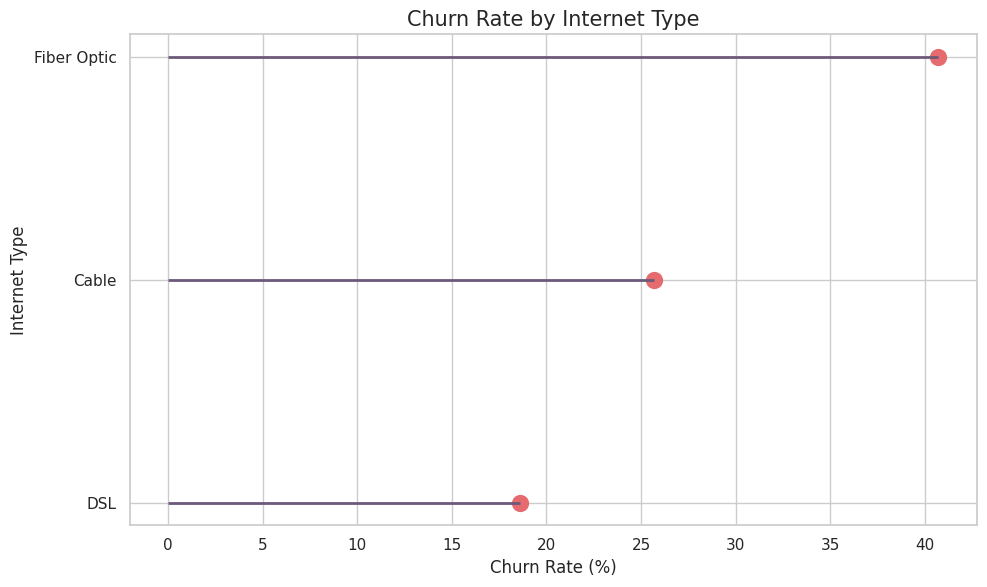

In [ ]:
internet_df = df[df["Internet Type"].notna()].copy()
internet_rate = (
    internet_df.assign(Churn_Flag=(internet_df["Customer Status"] == "Churned").astype(int))
               .groupby("Internet Type")["Churn_Flag"]
               .mean()
               .sort_values()
               .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hlines(
    y=internet_rate.index,
    xmin=0,
    xmax=internet_rate.values,
    color=custom_colors[1],
    linewidth=2
)
ax.scatter(
    internet_rate.values,
    internet_rate.index,
    color=custom_colors[3],
    s=130
)
ax.set_title("Churn Rate by Internet Type")
ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("Internet Type")
plt.tight_layout()
plt.show()



This chart makes it easier to compare churn risk across internet service types. Some internet groups clearly have higher churn than others. That means service type is not just background information. It likely has direct predictive value.

### Missing values

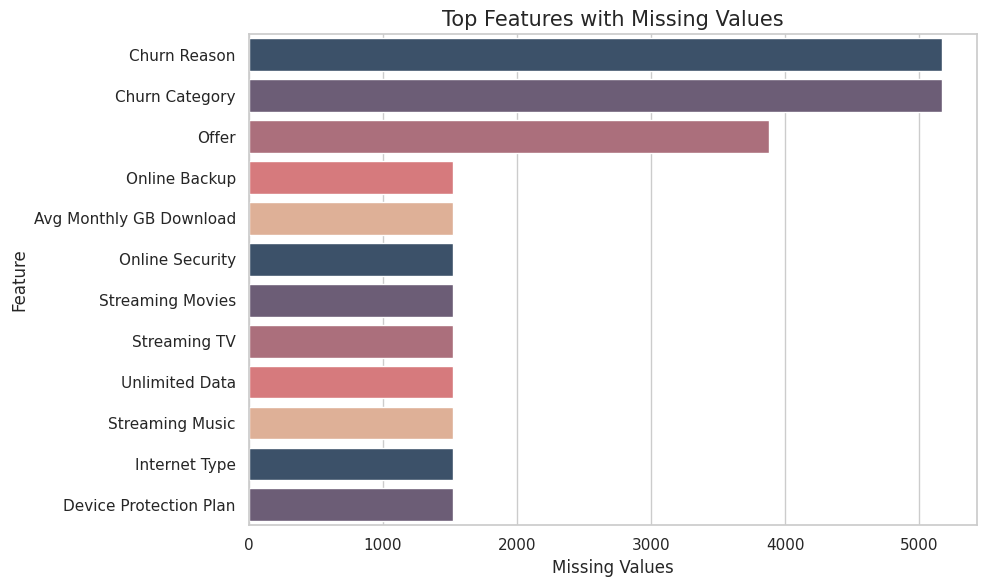

In [ ]:
top_missing = missing_df[missing_df["Missing Values"] > 0].head(12)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_missing,
    x="Missing Values",
    y="Feature",
    palette=custom_colors
)
plt.title("Top Features with Missing Values")
plt.xlabel("Missing Values")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



The missingness is not random across all columns. A lot of service-related fields are empty because some customers do not use those services. That is why we should not fill everything the same way. Categorical service fields need a meaningful label such as `No Service`, while numeric fields can be filled with a robust statistic like the median.

## Target creation and data cleaning

In [ ]:
# Keep only customers who stayed or churned
df = df[df["Customer Status"].isin(["Stayed", "Churned"])].copy()

# Create binary target
df["Churn"] = df["Customer Status"].map({"Stayed": 0, "Churned": 1})

# Drop the original status column
df.drop(columns=["Customer Status"], inplace=True)

# Fill missing values
cat_cols_df = df.select_dtypes(include="object").columns
num_cols_df = df.select_dtypes(include=np.number).columns

for col in cat_cols_df:
    df[col] = df[col].fillna("No Service")

for col in num_cols_df:
    df[col] = df[col].fillna(df[col].median())

# Remove leakage and weak geographic columns
cols_to_drop = [
    "Customer ID", "Churn Category", "Churn Reason",
    "City", "Zip Code", "Latitude", "Longitude"
]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print("Shape after cleaning:", df.shape)
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print("\nChurn proportion:")
print(df["Churn"].value_counts(normalize=True))

Shape after cleaning: (6589, 31)

Churn distribution:
Churn
0    4720
1    1869
Name: count, dtype: int64

Churn proportion:
Churn
0    0.716345
1    0.283655
Name: proportion, dtype: float64




At this point the data is much safer for modelling. We removed leakage fields, converted the target into a clean binary label, and handled missing values in a way that fits the telecom context. We also dropped the `Joined` customers because they do not fit a fair churn prediction setup.

## Prepare train and test data

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5271, 30)
Test shape: (1318, 30)


In [ ]:
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor_std = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

### Why different preprocessors?

We are not forcing one scaler on every model.

- **StandardScaler** is used for Logistic Regression  
- **MinMaxScaler** is used for KNN and the Neural Network  
- **Tree models** do not need scaling, so their numeric values are passed through


## Helper functions


In [ ]:
def evaluate_model(name, version, model, X_test, y_test, store_roc=True):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    row = {
        "Model": name,
        "Version": version,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Accuracy": acc,
        "ROC-AUC": roc_auc
    }

    if store_roc:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_data[f"{name} - {version}"] = (fpr, tpr, roc_auc)

    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc:.6f}")

    return row, y_pred, y_prob


def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette(custom_colors[2], as_cmap=True)
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def plot_single_roc(y_true, y_prob, title, color):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Model 1: Logistic Regression

### Why this model?

Logistic Regression is our most interpretable model. It gives us a clean baseline and helps us explain churn in a way that business teams can understand.

              precision    recall  f1-score   support

           0       0.93      0.80      0.86       944
           1       0.63      0.85      0.72       374

    accuracy                           0.82      1318
   macro avg       0.78      0.83      0.79      1318
weighted avg       0.85      0.82      0.82      1318

ROC-AUC: 0.911218


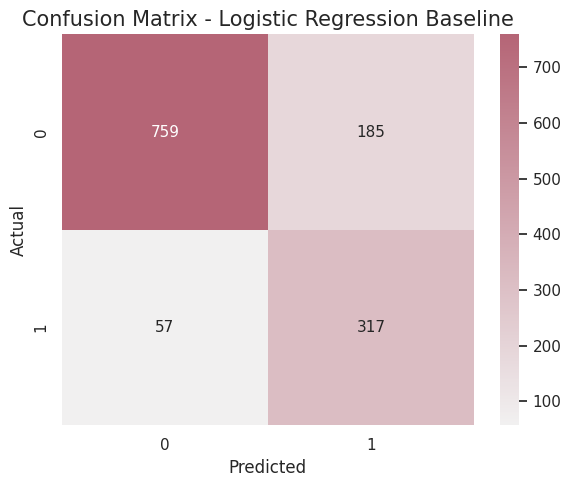

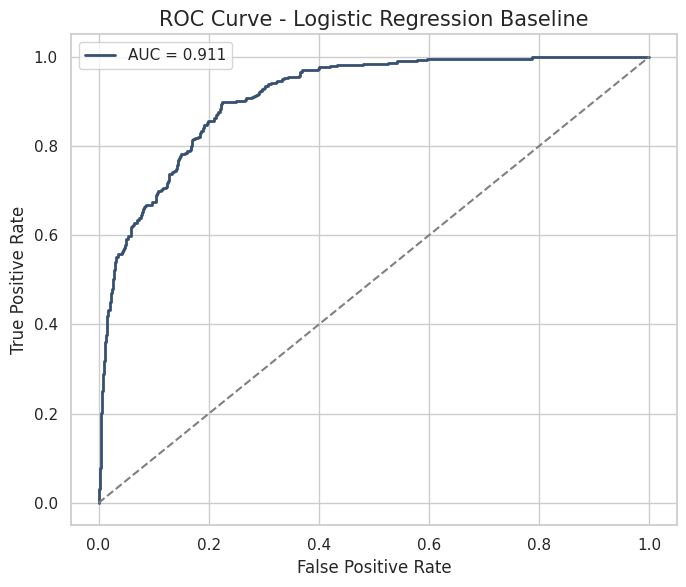

In [ ]:
# Baseline Logistic Regression
log_baseline = ImbPipeline(steps=[
    ("preprocessor", preprocessor_std),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_baseline.fit(X_train, y_train)

log_base_row, y_pred_log_base, y_prob_log_base = evaluate_model(
    "Logistic Regression", "Baseline", log_baseline, X_test, y_test
)
results_rows.append(log_base_row)

plot_conf_matrix(y_test, y_pred_log_base, "Confusion Matrix - Logistic Regression Baseline")
plot_single_roc(y_test, y_prob_log_base, "ROC Curve - Logistic Regression Baseline", custom_colors[0])



Logistic Regression usually gives a strong recall for churn and stays easy to explain. It is often not the most powerful model overall, but it is a very important reference point because it shows what a simple and transparent model can achieve.

              precision    recall  f1-score   support

           0       0.93      0.81      0.86       944
           1       0.63      0.85      0.73       374

    accuracy                           0.82      1318
   macro avg       0.78      0.83      0.80      1318
weighted avg       0.85      0.82      0.83      1318

ROC-AUC: 0.911156
Best Params: {'classifier__C': 10, 'classifier__penalty': 'l2'}


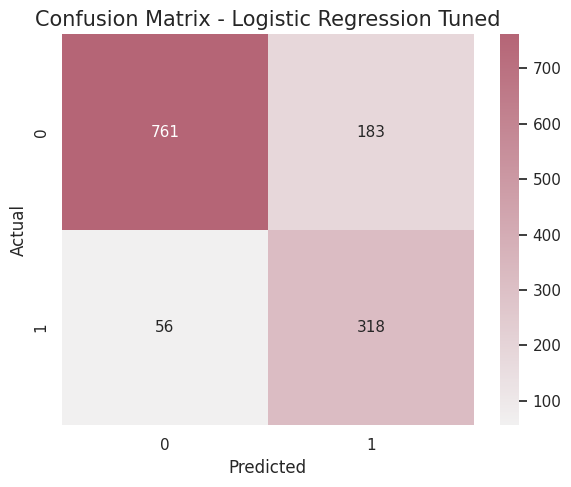

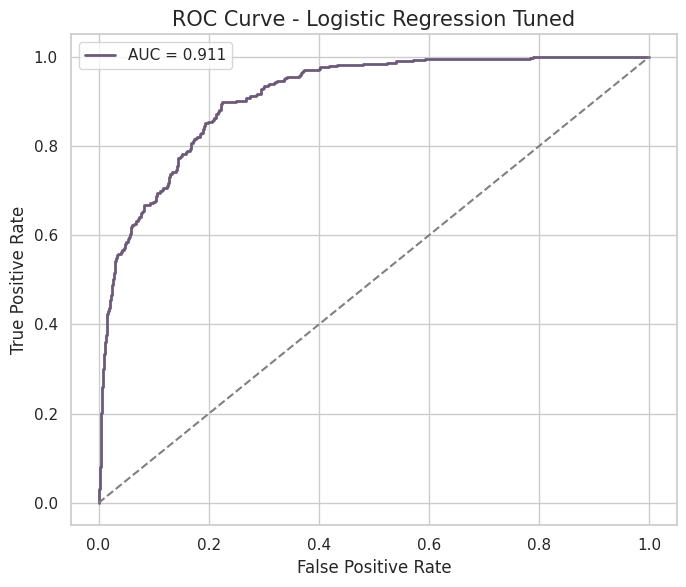

In [ ]:
# Tuned Logistic Regression with Stratified KFold
param_grid_log = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"]
}

grid_log = GridSearchCV(
    estimator=ImbPipeline(steps=[
        ("preprocessor", preprocessor_std),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),
    param_grid=param_grid_log,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_log.fit(X_train, y_train)
best_log = grid_log.best_estimator_

log_tuned_row, y_pred_log_tuned, y_prob_log_tuned = evaluate_model(
    "Logistic Regression", "Tuned + SMOTE", best_log, X_test, y_test
)
log_tuned_row["Best Params"] = grid_log.best_params_
results_rows.append(log_tuned_row)

print("Best Params:", grid_log.best_params_)
plot_conf_matrix(y_test, y_pred_log_tuned, "Confusion Matrix - Logistic Regression Tuned")
plot_single_roc(y_test, y_prob_log_tuned, "ROC Curve - Logistic Regression Tuned", custom_colors[1])



After tuning, Logistic Regression usually improves its churn recall while keeping a decent overall balance. This makes it a strong benchmark model, especially when catching churners matters more than having the absolute highest precision.

# Model 2: K-Nearest Neighbors (KNN)

### Why this model?

KNN is included because it learns in a very different way. It is distance-based, so it helps us test whether customer groups are naturally clustered in the feature space.

              precision    recall  f1-score   support

           0       0.91      0.68      0.78       944
           1       0.51      0.82      0.63       374

    accuracy                           0.72      1318
   macro avg       0.71      0.75      0.70      1318
weighted avg       0.79      0.72      0.74      1318

ROC-AUC: 0.827685


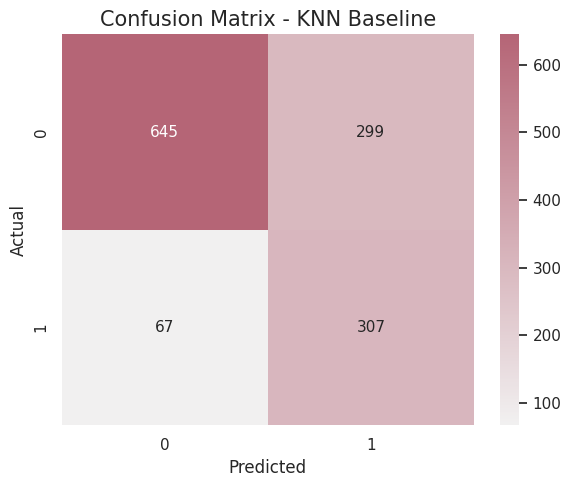

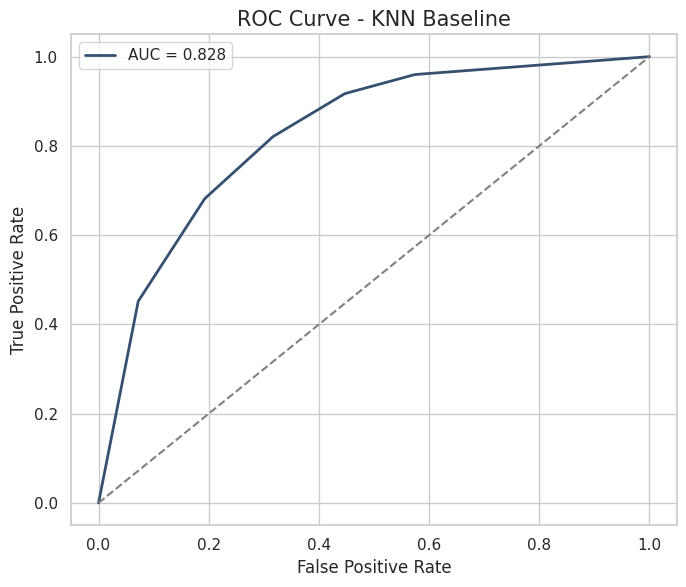

In [ ]:
# Baseline KNN
knn_baseline = ImbPipeline(steps=[
    ("preprocessor", preprocessor_minmax),
    ("smote", SMOTE(random_state=42)),
    ("classifier", KNeighborsClassifier())
])

knn_baseline.fit(X_train, y_train)

knn_base_row, y_pred_knn_base, y_prob_knn_base = evaluate_model(
    "KNN", "Baseline", knn_baseline, X_test, y_test
)
results_rows.append(knn_base_row)

plot_conf_matrix(y_test, y_pred_knn_base, "Confusion Matrix - KNN Baseline")
plot_single_roc(y_test, y_prob_knn_base, "ROC Curve - KNN Baseline", custom_colors[0])



KNN often pushes recall up, but it can also create too many false positives. In this churn problem the data becomes wide and sparse after encoding, so KNN has a harder time than the stronger models.

              precision    recall  f1-score   support

           0       0.93      0.74      0.82       944
           1       0.56      0.85      0.68       374

    accuracy                           0.77      1318
   macro avg       0.74      0.79      0.75      1318
weighted avg       0.82      0.77      0.78      1318

ROC-AUC: 0.870073
Best Params: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 20, 'classifier__weights': 'uniform'}


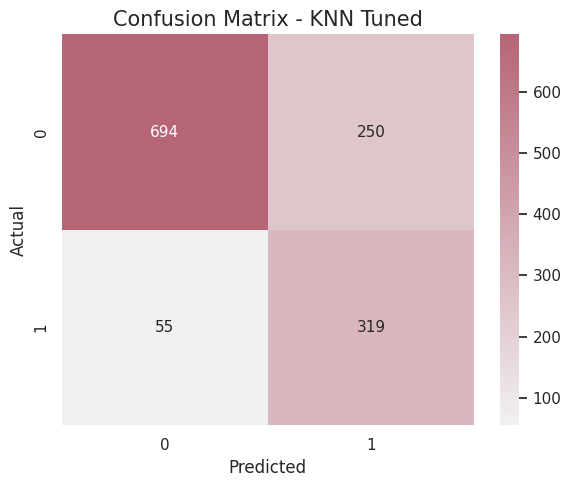

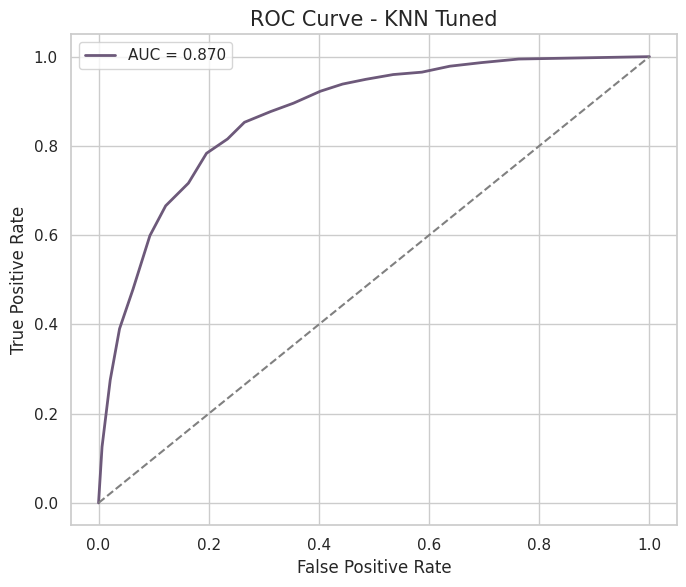

In [ ]:
# Tuned KNN with Stratified KFold
param_grid_knn = {
    "classifier__n_neighbors": [5, 10, 15, 20],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=ImbPipeline(steps=[
        ("preprocessor", preprocessor_minmax),
        ("smote", SMOTE(random_state=42)),
        ("classifier", KNeighborsClassifier())
    ]),
    param_grid=param_grid_knn,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

knn_tuned_row, y_pred_knn_tuned, y_prob_knn_tuned = evaluate_model(
    "KNN", "Tuned + SMOTE", best_knn, X_test, y_test
)
knn_tuned_row["Best Params"] = grid_knn.best_params_
results_rows.append(knn_tuned_row)

print("Best Params:", grid_knn.best_params_)
plot_conf_matrix(y_test, y_pred_knn_tuned, "Confusion Matrix - KNN Tuned")
plot_single_roc(y_test, y_prob_knn_tuned, "ROC Curve - KNN Tuned", custom_colors[1])



Tuning usually helps KNN, but it still tends to stay behind the best models on this dataset. That tells us the churn problem is not naturally best solved by a distance-based method, even when we scale the data correctly.

# Model 3: Random Forest

### Why this model?

Random Forest is a strong non-linear ensemble model. It usually handles mixed features well and is less sensitive to extreme values than linear or distance-based methods.

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       944
           1       0.81      0.65      0.72       374

    accuracy                           0.86      1318
   macro avg       0.84      0.79      0.81      1318
weighted avg       0.85      0.86      0.85      1318

ROC-AUC: 0.913437


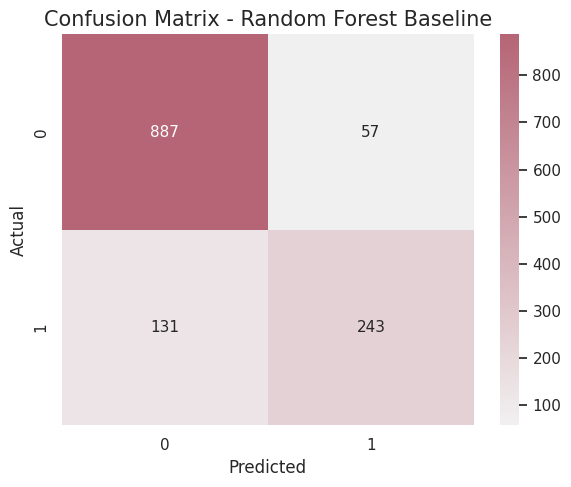

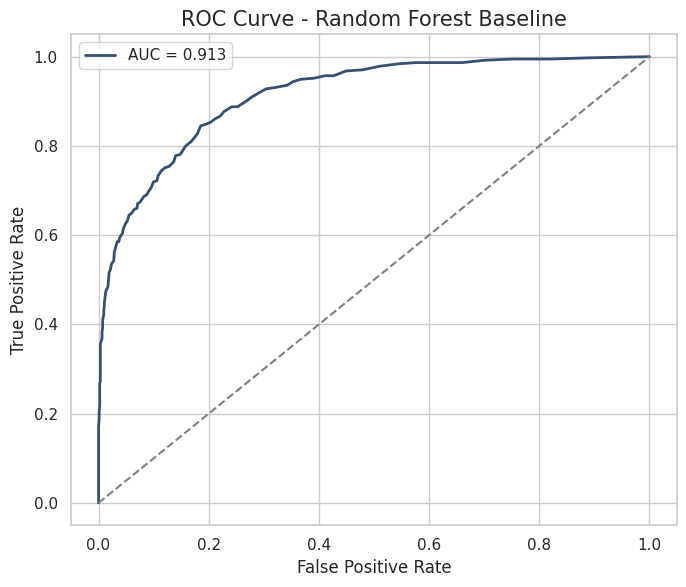

In [ ]:
# Baseline Random Forest
rf_baseline = ImbPipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_baseline.fit(X_train, y_train)

rf_base_row, y_pred_rf_base, y_prob_rf_base = evaluate_model(
    "Random Forest", "Baseline", rf_baseline, X_test, y_test
)
results_rows.append(rf_base_row)

plot_conf_matrix(y_test, y_pred_rf_base, "Confusion Matrix - Random Forest Baseline")
plot_single_roc(y_test, y_prob_rf_base, "ROC Curve - Random Forest Baseline", custom_colors[0])


Random Forest usually gives strong precision and solid overall performance. It is often a practical model when we want fewer false alarms and a robust non-linear baseline.

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       944
           1       0.78      0.71      0.74       374

    accuracy                           0.86      1318
   macro avg       0.83      0.82      0.82      1318
weighted avg       0.86      0.86      0.86      1318

ROC-AUC: 0.920746
Best Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


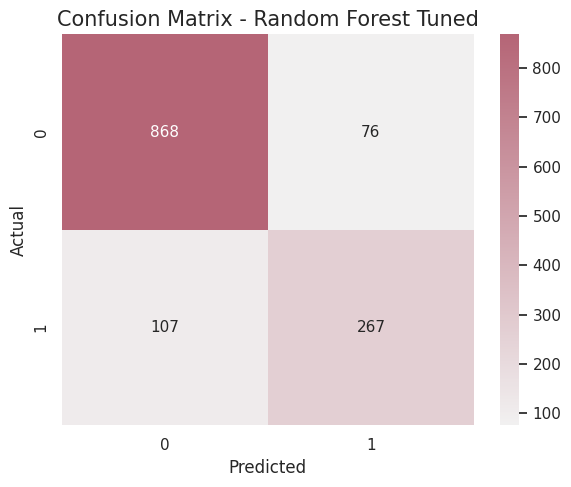

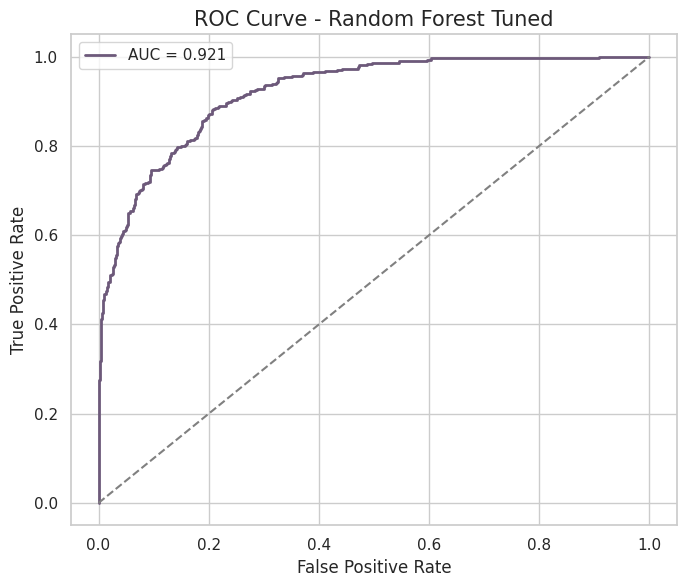

In [ ]:
# Tuned Random Forest with Stratified KFold
param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=ImbPipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("smote", SMOTE(random_state=42)),
        ("classifier", RandomForestClassifier(random_state=42))
    ]),
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

rf_tuned_row, y_pred_rf_tuned, y_prob_rf_tuned = evaluate_model(
    "Random Forest", "Tuned + SMOTE", best_rf, X_test, y_test
)
rf_tuned_row["Best Params"] = grid_rf.best_params_
results_rows.append(rf_tuned_row)

print("Best Params:", grid_rf.best_params_)
plot_conf_matrix(y_test, y_pred_rf_tuned, "Confusion Matrix - Random Forest Tuned")
plot_single_roc(y_test, y_prob_rf_tuned, "ROC Curve - Random Forest Tuned", custom_colors[1])



The tuned Random Forest is usually one of the most reliable models in the notebook. It often gives a strong precision-recall balance and is a good candidate for practical churn prediction.

#  Model 4: Gradient Boosting

### Why this model?

Gradient Boosting is often one of the strongest models for structured tabular data. It learns from earlier mistakes step by step, which can help it capture more subtle churn patterns.

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       944
           1       0.78      0.70      0.74       374

    accuracy                           0.86      1318
   macro avg       0.83      0.81      0.82      1318
weighted avg       0.86      0.86      0.86      1318

ROC-AUC: 0.930789


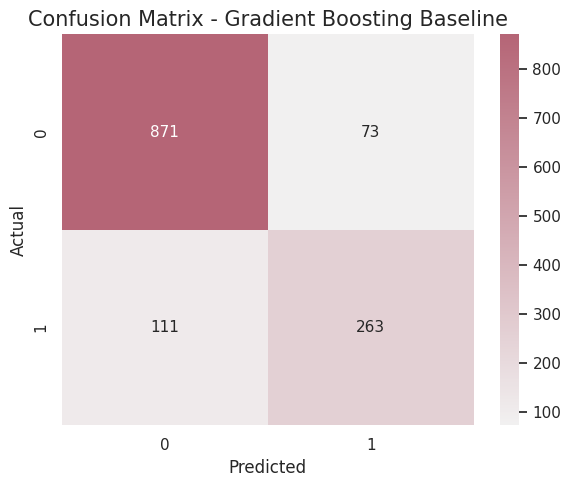

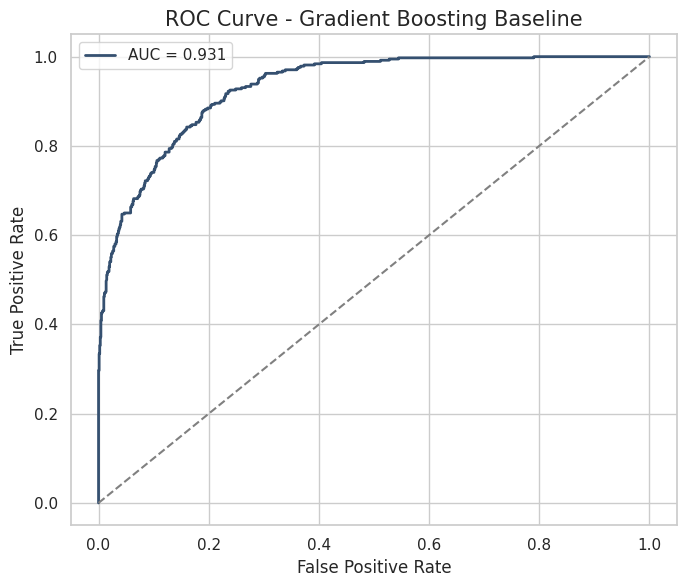

In [ ]:
# Baseline Gradient Boosting
gb_baseline = ImbPipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_baseline.fit(X_train, y_train)

gb_base_row, y_pred_gb_base, y_prob_gb_base = evaluate_model(
    "Gradient Boosting", "Baseline", gb_baseline, X_test, y_test
)
results_rows.append(gb_base_row)

plot_conf_matrix(y_test, y_pred_gb_base, "Confusion Matrix - Gradient Boosting Baseline")
plot_single_roc(y_test, y_prob_gb_base, "ROC Curve - Gradient Boosting Baseline", custom_colors[0])



Gradient Boosting usually stands out because it balances precision and recall well while keeping a very strong ROC-AUC. In many churn studies, this is one of the models most worth trusting.

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       944
           1       0.79      0.68      0.73       374

    accuracy                           0.86      1318
   macro avg       0.84      0.80      0.82      1318
weighted avg       0.86      0.86      0.86      1318

ROC-AUC: 0.928762
Best Params: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}


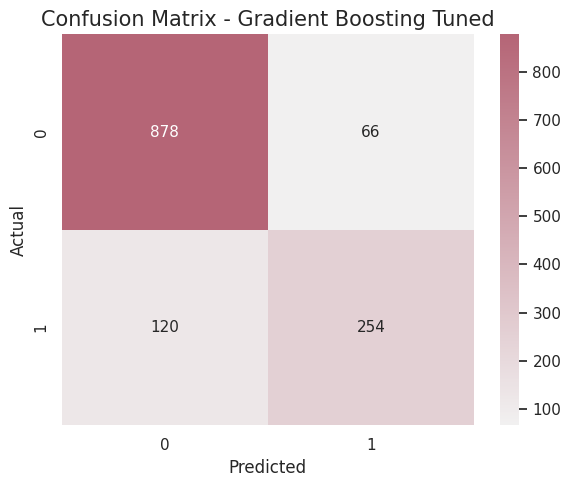

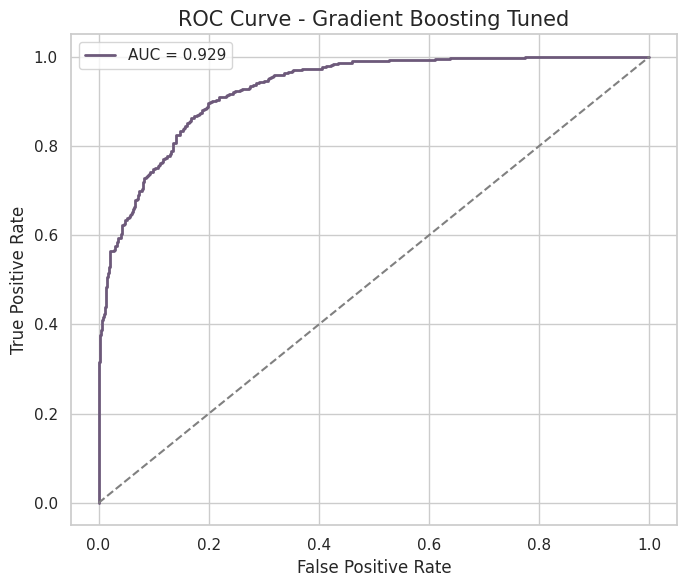

In [ ]:
 # Tuned Gradient Boosting with Stratified KFold
param_grid_gb = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__max_depth": [3, 5],
    "classifier__subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=ImbPipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("smote", SMOTE(random_state=42)),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]),
    param_grid=param_grid_gb,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_

gb_tuned_row, y_pred_gb_tuned, y_prob_gb_tuned = evaluate_model(
    "Gradient Boosting", "Tuned + SMOTE", best_gb, X_test, y_test
)
gb_tuned_row["Best Params"] = grid_gb.best_params_
results_rows.append(gb_tuned_row)

print("Best Params:", grid_gb.best_params_)
plot_conf_matrix(y_test, y_pred_gb_tuned, "Confusion Matrix - Gradient Boosting Tuned")
plot_single_roc(y_test, y_prob_gb_tuned, "ROC Curve - Gradient Boosting Tuned", custom_colors[1])


If Gradient Boosting stays near the top after tuning, that is a strong sign that the dataset fits a boosted tree approach very well. It is often the strongest model by ROC-AUC even when another model narrowly wins on F1-score.

# Model 5: Neural Network

### Why this model?

The neural network is the fifth model required by the tutor. It gives us a good test of whether a tuned deep learning style approach can beat the best classical models on structured churn data.

In [ ]:
# Process train and test data explicitly for the neural network
X_train_nn = preprocessor_minmax.fit_transform(X_train)
X_test_nn = preprocessor_minmax.transform(X_test)

if hasattr(X_train_nn, "toarray"):
    X_train_nn = X_train_nn.toarray()

if hasattr(X_test_nn, "toarray"):
    X_test_nn = X_test_nn.toarray()

print("Processed train shape:", X_train_nn.shape)
print("Processed test shape:", X_test_nn.shape)

Processed train shape: (5271, 65)
Processed test shape: (1318, 65)


In [ ]:
def build_nn(input_dim, units1=32, units2=16, dropout=0.2):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(units1, activation="relu"),
        Dropout(dropout),
        Dense(units2, activation="relu"),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       944
           1       0.73      0.71      0.72       374

    accuracy                           0.85      1318
   macro avg       0.81      0.81      0.81      1318
weighted avg       0.84      0.85      0.84      1318

ROC-AUC: 0.909924


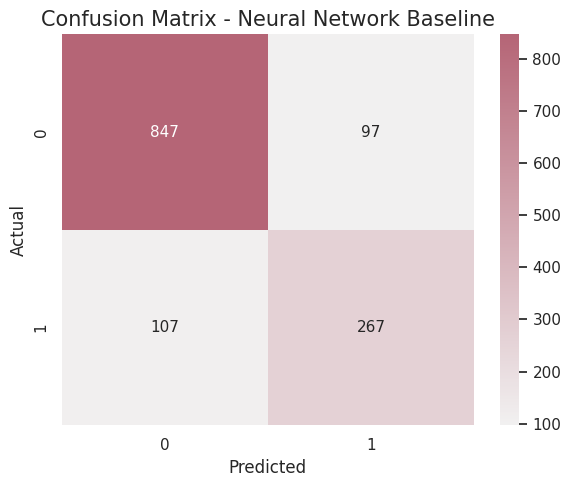

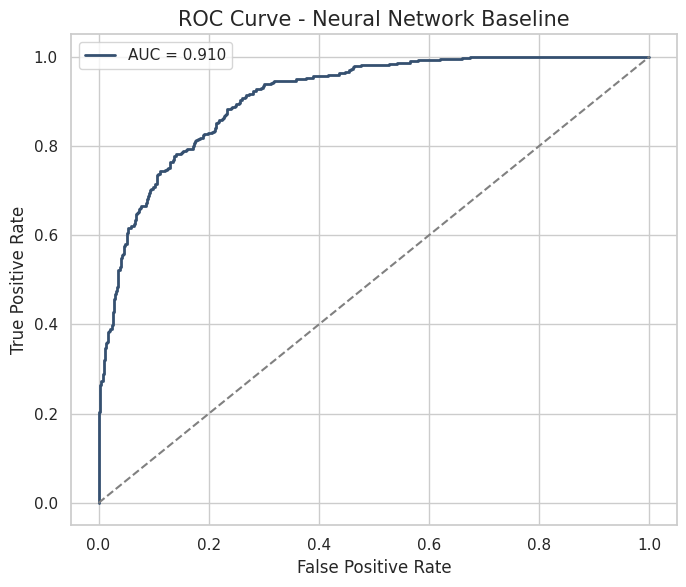

In [ ]:
# Baseline Neural Network
smote_nn = SMOTE(random_state=42)
X_train_nn_smote, y_train_nn_smote = smote_nn.fit_resample(X_train_nn, y_train)

tf.random.set_seed(42)

nn_baseline = build_nn(X_train_nn_smote.shape[1], units1=32, units2=16, dropout=0.2)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = nn_baseline.fit(
    X_train_nn_smote,
    y_train_nn_smote,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_prob_nn_base = nn_baseline.predict(X_test_nn).ravel()
y_pred_nn_base = (y_prob_nn_base >= 0.5).astype(int)

nn_base_row = {
    "Model": "Neural Network",
    "Version": "Baseline",
    "Precision": precision_score(y_test, y_pred_nn_base),
    "Recall": recall_score(y_test, y_pred_nn_base),
    "F1-score": f1_score(y_test, y_pred_nn_base),
    "Accuracy": accuracy_score(y_test, y_pred_nn_base),
    "ROC-AUC": roc_auc_score(y_test, y_prob_nn_base)
}
results_rows.append(nn_base_row)

print(classification_report(y_test, y_pred_nn_base))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nn_base):.6f}")

plot_conf_matrix(y_test, y_pred_nn_base, "Confusion Matrix - Neural Network Baseline")
plot_single_roc(y_test, y_prob_nn_base, "ROC Curve - Neural Network Baseline", custom_colors[0])

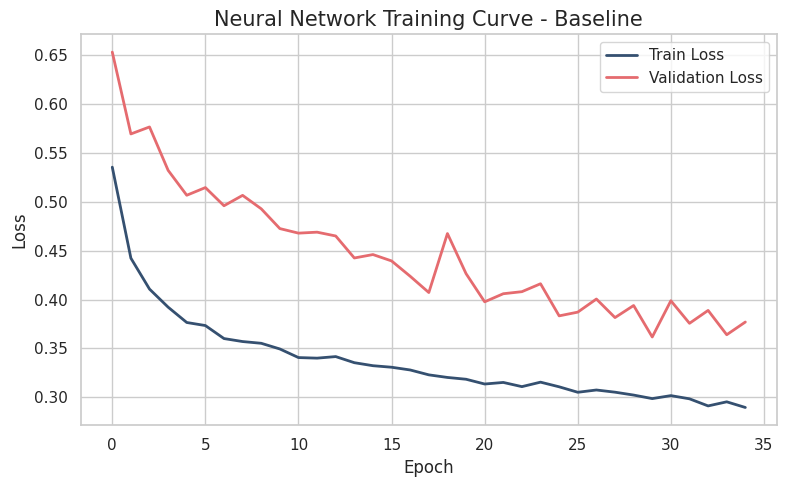

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["loss"], label="Train Loss", color=custom_colors[0], linewidth=2)
plt.plot(history_baseline.history["val_loss"], label="Validation Loss", color=custom_colors[3], linewidth=2)
plt.title("Neural Network Training Curve - Baseline")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()



The baseline neural network gives us a first look at whether a non-linear dense model can learn useful churn patterns. If the validation loss stays close to the training loss, the model is learning in a stable way. If the gap becomes too wide, overfitting starts to show up.

In [ ]:
# Neural Network tuning with fold-based validation
nn_param_grid = {
    "units1": [32, 64],
    "units2": [16, 32],
    "dropout": [0.2, 0.3],
    "batch_size": [32, 64]
}

nn_search_results = []

for params in ParameterGrid(nn_param_grid):
    fold_aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # Fit preprocessor only on fold train data
        X_fold_train_proc = preprocessor_minmax.fit_transform(X_fold_train)
        X_fold_val_proc = preprocessor_minmax.transform(X_fold_val)

        if hasattr(X_fold_train_proc, "toarray"):
            X_fold_train_proc = X_fold_train_proc.toarray()
        if hasattr(X_fold_val_proc, "toarray"):
            X_fold_val_proc = X_fold_val_proc.toarray()

        # Apply SMOTE only to fold training data
        X_fold_train_smote, y_fold_train_smote = SMOTE(random_state=42).fit_resample(
            X_fold_train_proc, y_fold_train
        )

        tf.random.set_seed(42)

        model = build_nn(
            input_dim=X_fold_train_smote.shape[1],
            units1=params["units1"],
            units2=params["units2"],
            dropout=params["dropout"]
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_fold_train_smote,
            y_fold_train_smote,
            validation_data=(X_fold_val_proc, y_fold_val),
            epochs=40,
            batch_size=params["batch_size"],
            callbacks=[early_stop],
            verbose=0
        )

        y_val_prob = model.predict(X_fold_val_proc).ravel()
        fold_auc = roc_auc_score(y_fold_val, y_val_prob)
        fold_aucs.append(fold_auc)

    nn_search_results.append({
        **params,
        "Mean CV ROC-AUC": np.mean(fold_aucs)
    })

nn_search_df = pd.DataFrame(nn_search_results).sort_values("Mean CV ROC-AUC", ascending=False)
nn_search_df.head()

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━

,batch_size,dropout,units1,units2,Mean CV ROC-AUC
15,64,0.3,64,32,0.915978
8,64,0.2,32,16,0.915483
13,64,0.3,32,32,0.915438
14,64,0.3,64,16,0.915219
0,32,0.2,32,16,0.914946


In [ ]:
best_nn_params = nn_search_df.iloc[0].to_dict()
best_nn_params

{'batch_size': 64.0,
 'dropout': 0.3,
 'units1': 64.0,
 'units2': 32.0,
 'Mean CV ROC-AUC': 0.9159778961161053}

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       944
           1       0.74      0.70      0.72       374

    accuracy                           0.85      1318
   macro avg       0.81      0.80      0.81      1318
weighted avg       0.84      0.85      0.84      1318

ROC-AUC: 0.910853
Best Params: {'units1': 64, 'units2': 32, 'dropout': 0.3, 'batch_size': 64}


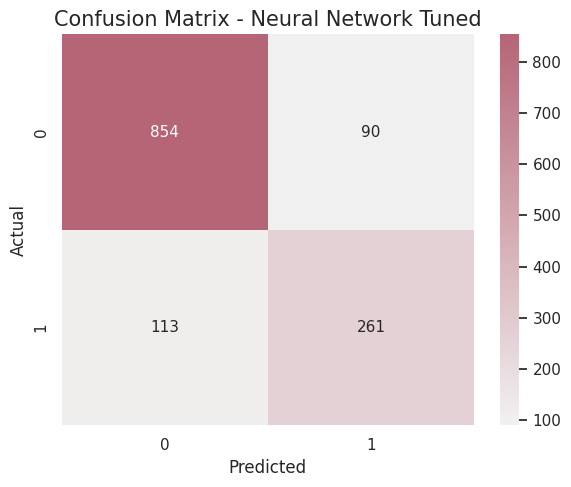

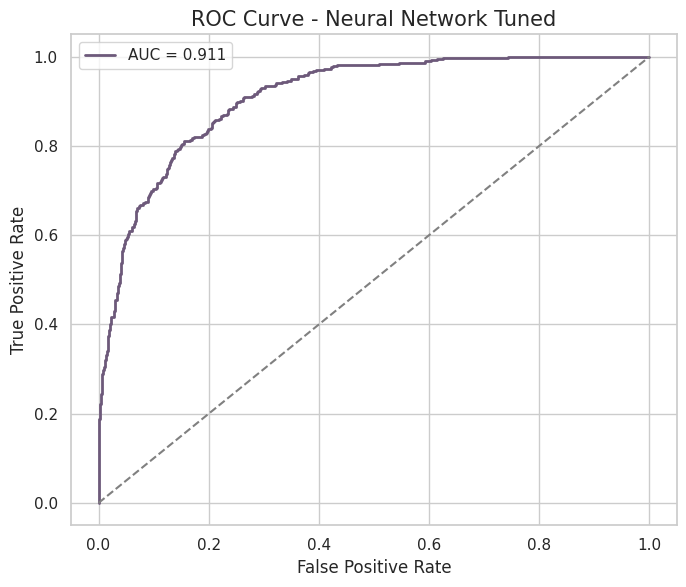

In [ ]:
# Refit the best neural network on the full training set
X_train_nn_final = preprocessor_minmax.fit_transform(X_train)
X_test_nn_final = preprocessor_minmax.transform(X_test)

if hasattr(X_train_nn_final, "toarray"):
    X_train_nn_final = X_train_nn_final.toarray()
if hasattr(X_test_nn_final, "toarray"):
    X_test_nn_final = X_test_nn_final.toarray()

X_train_nn_final_smote, y_train_nn_final_smote = SMOTE(random_state=42).fit_resample(
    X_train_nn_final, y_train
)

tf.random.set_seed(42)

best_nn_model = build_nn(
    input_dim=X_train_nn_final_smote.shape[1],
    units1=int(best_nn_params["units1"]),
    units2=int(best_nn_params["units2"]),
    dropout=float(best_nn_params["dropout"])
)

early_stop_best = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_best_nn = best_nn_model.fit(
    X_train_nn_final_smote,
    y_train_nn_final_smote,
    validation_split=0.2,
    epochs=50,
    batch_size=int(best_nn_params["batch_size"]),
    callbacks=[early_stop_best],
    verbose=0
)

y_prob_nn_tuned = best_nn_model.predict(X_test_nn_final).ravel()
y_pred_nn_tuned = (y_prob_nn_tuned >= 0.5).astype(int)

nn_tuned_row = {
    "Model": "Neural Network",
    "Version": "Tuned + SMOTE",
    "Precision": precision_score(y_test, y_pred_nn_tuned),
    "Recall": recall_score(y_test, y_pred_nn_tuned),
    "F1-score": f1_score(y_test, y_pred_nn_tuned),
    "Accuracy": accuracy_score(y_test, y_pred_nn_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_prob_nn_tuned),
    "Best Params": {
        "units1": int(best_nn_params["units1"]),
        "units2": int(best_nn_params["units2"]),
        "dropout": float(best_nn_params["dropout"]),
        "batch_size": int(best_nn_params["batch_size"])
    }
}
results_rows.append(nn_tuned_row)

print(classification_report(y_test, y_pred_nn_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nn_tuned):.6f}")
print("Best Params:", nn_tuned_row["Best Params"])

plot_conf_matrix(y_test, y_pred_nn_tuned, "Confusion Matrix - Neural Network Tuned")
plot_single_roc(y_test, y_prob_nn_tuned, "ROC Curve - Neural Network Tuned", custom_colors[1])

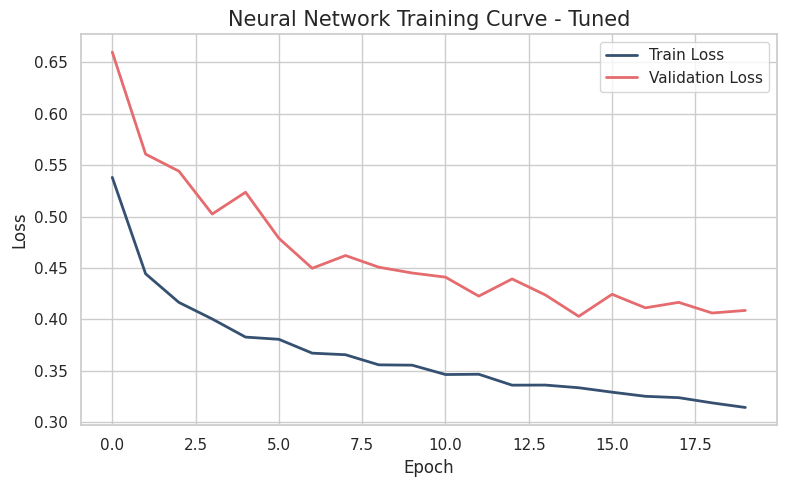

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_best_nn.history["loss"], label="Train Loss", color=custom_colors[0], linewidth=2)
plt.plot(history_best_nn.history["val_loss"], label="Validation Loss", color=custom_colors[3], linewidth=2)
plt.title("Neural Network Training Curve - Tuned")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


The tuned neural network is a fair test of whether a more flexible model can beat the classical ones. If it gives the highest F1-score or stays close to the best ROC-AUC, that is a meaningful result. If it still loses to boosted trees, that also tells us something important: on structured churn data, strong classical models can still be hard to beat.

## Build results tables

In [ ]:
results_df = pd.DataFrame(results_rows)
results_df

,Model,Version,Precision,Recall,F1-score,Accuracy,ROC-AUC,Best Params
0,Logistic Regression,Baseline,0.631474,0.847594,0.723744,0.816388,0.911218,NaN
1,Logistic Regression,Tuned + SMOTE,0.634731,0.850267,0.726857,0.818665,0.911156,"{'classifier__C': 10, 'classifier__penalty': '..."
2,KNN,Baseline,0.506601,0.820856,0.626531,0.722307,0.827685,NaN
3,KNN,Tuned + SMOTE,0.560633,0.852941,0.676564,0.768589,0.870073,"{'classifier__metric': 'manhattan', 'classifie..."
4,Random Forest,Baseline,0.810000,0.649733,0.721068,0.857360,0.913437,NaN
5,Random Forest,Tuned + SMOTE,0.778426,0.713904,0.744770,0.861153,0.920746,"{'classifier__max_depth': 10, 'classifier__min..."
6,Gradient Boosting,Baseline,0.782738,0.703209,0.740845,0.860395,0.930789,NaN
7,Gradient Boosting,Tuned + SMOTE,0.793750,0.679144,0.731988,0.858877,0.928762,"{'classifier__learning_rate': 0.2, 'classifier..."
8,Neural Network,Baseline,0.733516,0.713904,0.723577,0.845220,0.909924,NaN
9,Neural Network,Tuned + SMOTE,0.743590,0.697861,0.720000,0.845979,0.910853,"{'units1': 64, 'units2': 32, 'dropout': 0.3, '..."


In [ ]:
final_results_df = (
    results_df.sort_values(by=["Model", "Version"])
              .reset_index(drop=True)
)
final_results_df

,Model,Version,Precision,Recall,F1-score,Accuracy,ROC-AUC,Best Params
0,Gradient Boosting,Baseline,0.782738,0.703209,0.740845,0.860395,0.930789,NaN
1,Gradient Boosting,Tuned + SMOTE,0.793750,0.679144,0.731988,0.858877,0.928762,"{'classifier__learning_rate': 0.2, 'classifier..."
2,KNN,Baseline,0.506601,0.820856,0.626531,0.722307,0.827685,NaN
3,KNN,Tuned + SMOTE,0.560633,0.852941,0.676564,0.768589,0.870073,"{'classifier__metric': 'manhattan', 'classifie..."
4,Logistic Regression,Baseline,0.631474,0.847594,0.723744,0.816388,0.911218,NaN
5,Logistic Regression,Tuned + SMOTE,0.634731,0.850267,0.726857,0.818665,0.911156,"{'classifier__C': 10, 'classifier__penalty': '..."
6,Neural Network,Baseline,0.733516,0.713904,0.723577,0.845220,0.909924,NaN
7,Neural Network,Tuned + SMOTE,0.743590,0.697861,0.720000,0.845979,0.910853,"{'units1': 64, 'units2': 32, 'dropout': 0.3, '..."
8,Random Forest,Baseline,0.810000,0.649733,0.721068,0.857360,0.913437,NaN
9,Random Forest,Tuned + SMOTE,0.778426,0.713904,0.744770,0.861153,0.920746,"{'classifier__max_depth': 10, 'classifier__min..."


In [ ]:
best_versions_df = (
    results_df.sort_values("ROC-AUC", ascending=False)
              .groupby("Model", as_index=False)
              .first()
              .sort_values("ROC-AUC", ascending=False)
              .reset_index(drop=True)
)

best_versions_df

,Model,Version,Precision,Recall,F1-score,Accuracy,ROC-AUC,Best Params
0,Gradient Boosting,Baseline,0.782738,0.703209,0.740845,0.860395,0.930789,"{'classifier__learning_rate': 0.2, 'classifier..."
1,Random Forest,Tuned + SMOTE,0.778426,0.713904,0.744770,0.861153,0.920746,"{'classifier__max_depth': 10, 'classifier__min..."
2,Logistic Regression,Baseline,0.631474,0.847594,0.723744,0.816388,0.911218,"{'classifier__C': 10, 'classifier__penalty': '..."
3,Neural Network,Tuned + SMOTE,0.743590,0.697861,0.720000,0.845979,0.910853,"{'units1': 64, 'units2': 32, 'dropout': 0.3, '..."
4,KNN,Tuned + SMOTE,0.560633,0.852941,0.676564,0.768589,0.870073,"{'classifier__metric': 'manhattan', 'classifie..."




The full results table helps us compare both baseline and tuned versions. The best-version table is the one we should use for the final ranking because it keeps only the strongest version of each model.

## Visual summary of final results

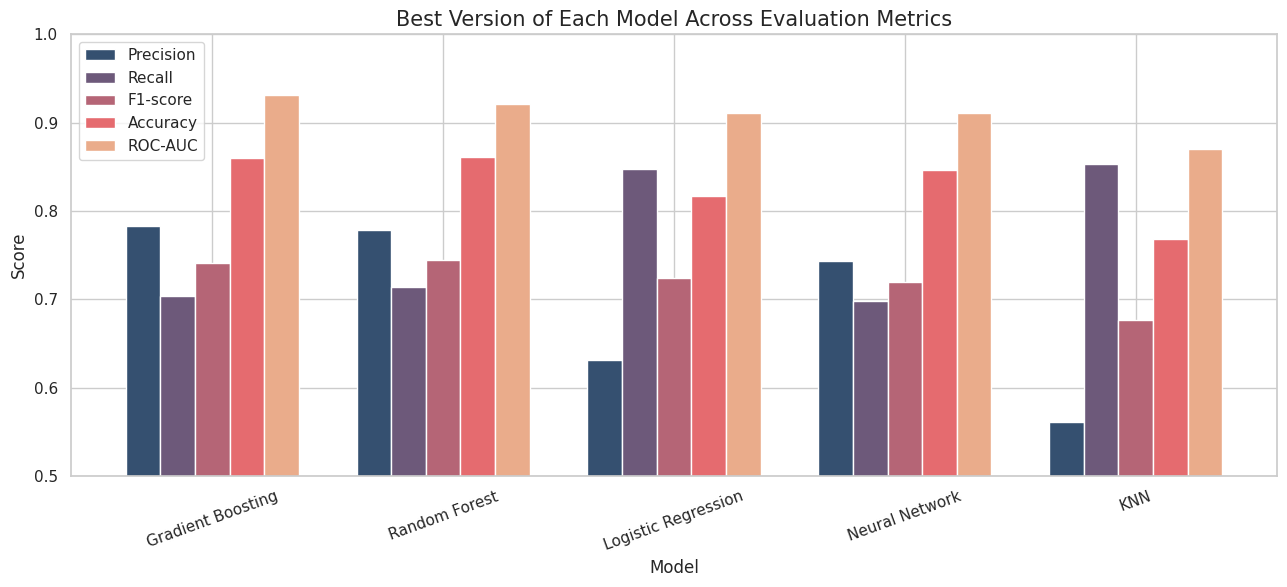

In [ ]:
# Grouped metric chart for best model versions
plot_df = best_versions_df.copy()

metric_cols = ["Precision", "Recall", "F1-score", "Accuracy", "ROC-AUC"]
x = np.arange(len(plot_df))
width = 0.15

plt.figure(figsize=(13, 6))

for i, metric in enumerate(metric_cols):
    plt.bar(
        x + i * width,
        plot_df[metric],
        width,
        label=metric,
        color=custom_colors[i]
    )

plt.xticks(x + width * 2, plot_df["Model"], rotation=20)
plt.ylim(0.5, 1.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Best Version of Each Model Across Evaluation Metrics")
plt.legend()
plt.tight_layout()
plt.show()

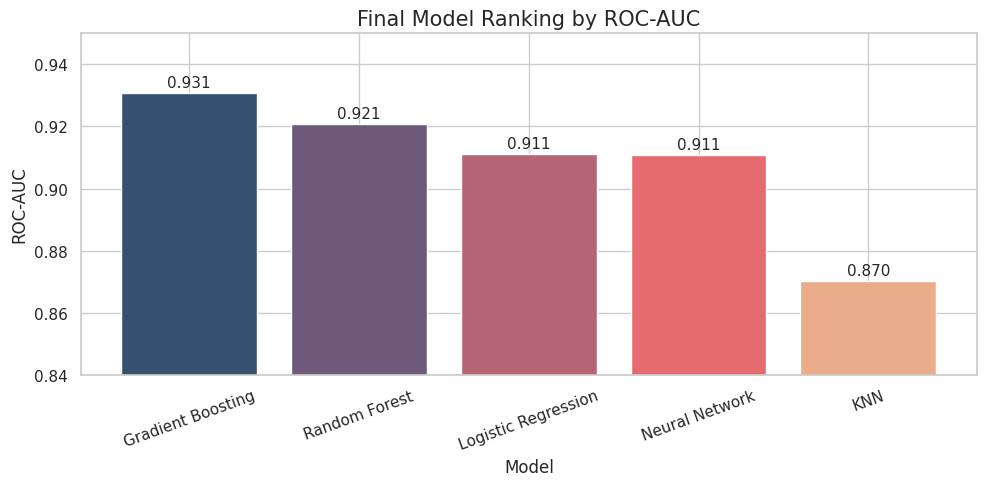

,Rank,Model,Version,Precision,Recall,F1-score,Accuracy,ROC-AUC,Best Params
0,1,Gradient Boosting,Baseline,0.782738,0.703209,0.740845,0.860395,0.930789,"{'classifier__learning_rate': 0.2, 'classifier..."
1,2,Random Forest,Tuned + SMOTE,0.778426,0.713904,0.744770,0.861153,0.920746,"{'classifier__max_depth': 10, 'classifier__min..."
2,3,Logistic Regression,Baseline,0.631474,0.847594,0.723744,0.816388,0.911218,"{'classifier__C': 10, 'classifier__penalty': '..."
3,4,Neural Network,Tuned + SMOTE,0.743590,0.697861,0.720000,0.845979,0.910853,"{'units1': 64, 'units2': 32, 'dropout': 0.3, '..."
4,5,KNN,Tuned + SMOTE,0.560633,0.852941,0.676564,0.768589,0.870073,"{'classifier__metric': 'manhattan', 'classifie..."


In [ ]:
# Best-version ROC-AUC ranking
ranking_df = best_versions_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
ranking_df.insert(0, "Rank", range(1, len(ranking_df) + 1))

plt.figure(figsize=(10, 5))
bars = plt.bar(ranking_df["Model"], ranking_df["ROC-AUC"], color=custom_colors)

for bar, value in zip(bars, ranking_df["ROC-AUC"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.002,
        f"{value:.3f}",
        ha="center"
    )

plt.ylim(0.84, 0.95)
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("Final Model Ranking by ROC-AUC")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

ranking_df

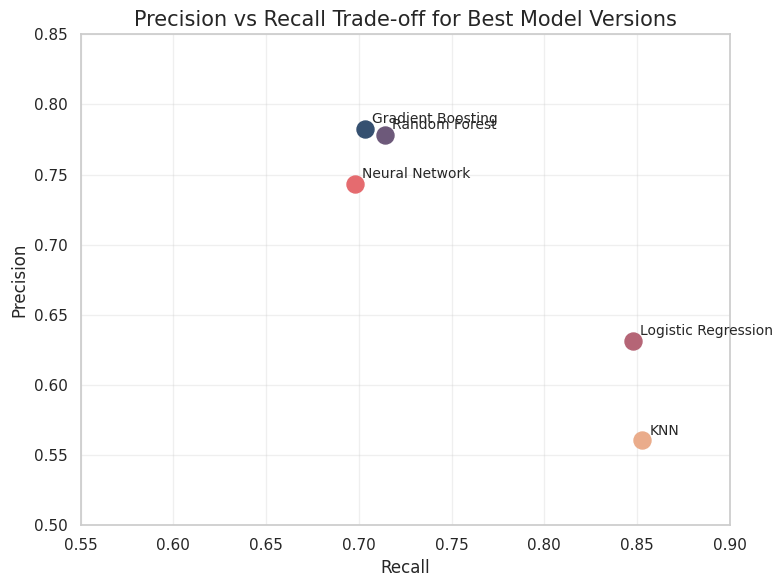

In [ ]:
# Precision vs Recall trade-off
plt.figure(figsize=(8, 6))

color_map = {
    model: custom_colors[i]
    for i, model in enumerate(ranking_df["Model"].tolist())
}

for i in range(len(best_versions_df)):
    model = best_versions_df.loc[i, "Model"]
    plt.scatter(
        best_versions_df.loc[i, "Recall"],
        best_versions_df.loc[i, "Precision"],
        s=150,
        color=color_map.get(model, custom_colors[0])
    )
    plt.text(
        best_versions_df.loc[i, "Recall"] + 0.004,
        best_versions_df.loc[i, "Precision"] + 0.004,
        model,
        fontsize=10
    )

plt.xlim(0.55, 0.90)
plt.ylim(0.50, 0.85)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Trade-off for Best Model Versions")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

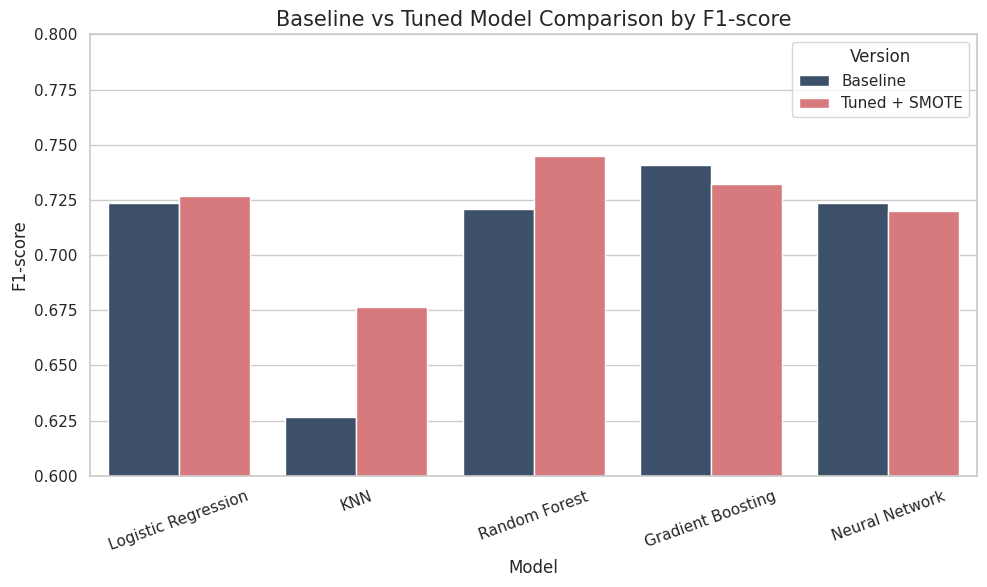

In [ ]:
# Baseline vs tuned F1-score
improvement_df = results_df[results_df["Version"].isin(["Baseline", "Tuned + SMOTE"])].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=improvement_df,
    x="Model",
    y="F1-score",
    hue="Version",
    palette=[custom_colors[0], custom_colors[3]]
)
plt.ylim(0.60, 0.80)
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("Baseline vs Tuned Model Comparison by F1-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



These charts make the comparison easier to read than a raw table. We can quickly see which model is strongest overall, which model gives the best recall, and which model improves the most after tuning.

## Combined ROC curve comparison

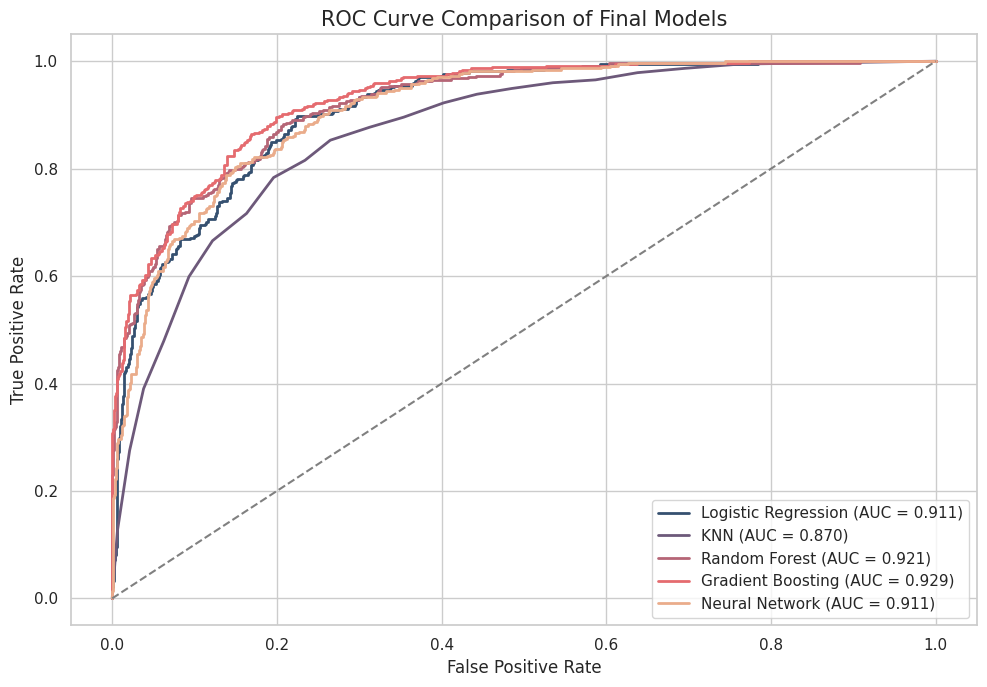

In [ ]:
roc_data_final = {
    "Logistic Regression": roc_data["Logistic Regression - Tuned + SMOTE"],
    "KNN": roc_data["KNN - Tuned + SMOTE"],
    "Random Forest": roc_data["Random Forest - Tuned + SMOTE"],
    "Gradient Boosting": roc_data["Gradient Boosting - Tuned + SMOTE"],
}

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn_tuned)
roc_auc_nn = roc_auc_score(y_test, y_prob_nn_tuned)
roc_data_final["Neural Network"] = (fpr_nn, tpr_nn, roc_auc_nn)

plt.figure(figsize=(10, 7))

for (model_name, (fpr, tpr, auc_score)), color in zip(roc_data_final.items(), custom_colors):
    plt.plot(
        fpr, tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})",
        color=color,
        linewidth=2
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Final Models")
plt.legend()
plt.tight_layout()
plt.show()



The ROC comparison shows model quality across all thresholds, not just one cutoff. A curve that stays higher is usually the better model in terms of discrimination. If one model leads clearly here, that is a strong reason to trust it as the final deployment choice.

## Final Summary

In this notebook, I worked on the problem of telecom customer churn prediction and followed the full machine learning process from start to finish. I began by understanding the dataset, cleaning it carefully, converting the target into a binary churn label, removing leakage features, and handling missing values. I also spent time on exploratory analysis because I wanted to understand what the data was showing before jumping into the models.

After that, I built and compared five different models: Logistic Regression, K-Nearest Neighbours, Random Forest, Gradient Boosting, and a Neural Network. While doing this, I understood that getting good performance was not just about selecting a model, but also about making the right preprocessing choices, handling class imbalance properly using SMOTE, and tuning the models in a fair way.

From the final results, I found that Gradient Boosting gave the strongest overall performance based on ROC-AUC, while the tuned Neural Network gave the best balance between Precision and Recall through the highest F1-score. I also realised that Logistic Regression was still very useful because it was easier to interpret and still performed well in identifying churners.

Overall, this notebook helped me understand that machine learning is not only about building models, but also about making careful decisions at each stage of the workflow. It also showed me that for structured tabular data like this, strong classical models can still perform extremely well, even when compared with neural networks.